In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import Lasso, OrthogonalMatchingPursuit
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler


In [2]:
# ======================================================
# 1. LOAD DATA
# ======================================================

X_emb = np.load("./data/mnist_emb_model1.npy")  # (N, d)
X_emb = StandardScaler().fit_transform(X_emb)
X_emb = X_emb[:2000].T  # -> (d, N)

d, N = X_emb.shape
n_atoms = 256
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Data shape:", X_emb.shape)

Data shape: (128, 2000)


In [3]:
X_emb[0, :].mean()

np.float32(0.018429609)

In [4]:
# ======================================================
# 2. INITIAL DICTIONARY
# ======================================================

def normalize_columns(D):
    return D / (np.linalg.norm(D, axis=0, keepdims=True) + 1e-8)

D_init = normalize_columns(np.random.randn(d, n_atoms))

In [5]:
def compute_metrics(X, D, R, name=""):
    X_hat = D @ R  # (d, N)

    errors = (
        np.linalg.norm(X - X_hat, axis=0) /
        np.linalg.norm(X, axis=0)
    ) * 100

    sparsity = np.sum(np.abs(R) > 1e-4, axis=0)
    sparsity_ratio = np.mean(np.abs(R) > 1e-4)

    print(f"\n===== {name} =====")
    print(f"Avg error: {errors.mean():.4f}")
    print(f"Std error: {errors.std():.4f}")
    print(f"Avg sparsity: {sparsity.mean():.2f}")
    print(f"Sparsity ratio: {sparsity_ratio:.4f}")

    return errors, sparsity


In [6]:
import torch
import numpy as np
from utils import SingleUserADMMDict


# ----------------------------
# Synthetic data
# ----------------------------
np.random.seed(0)
torch.manual_seed(0)

d = X_emb.shape[0]
n = X_emb.shape[1]
K = int(X_emb.shape[0] * 3.0)
k_sparsity = int(d * 0.1)


# ----------------------------
# Train model
# ----------------------------
model = SingleUserADMMDict(
    d=d,
    K=K,
    k_sparsity=k_sparsity,
    rho=5,
    admm_iters=30
)

X_emb_tensor = torch.from_numpy(X_emb).float()


D_hat, S_hat, losses = model.fit(X_emb_tensor, outer_iters=100)


# ----------------------------
# Evaluation
# ----------------------------
print("\nFinal loss:", losses[-1])

print("\nSparsity check (active atoms):")
active = torch.sum(torch.norm(S_hat, dim=1) > 1e-6).item()
print("Active atoms:", active, "/", K)


iter 0: loss=366.539307
iter 1: loss=48.126644
iter 2: loss=38.136490
iter 3: loss=36.849434
iter 4: loss=36.439434
iter 5: loss=36.206329
iter 6: loss=36.039795
iter 7: loss=35.907288
iter 8: loss=35.793858
iter 9: loss=35.696091
iter 10: loss=35.612843
iter 11: loss=35.543015
iter 12: loss=35.485977
iter 13: loss=35.440338
iter 14: loss=35.404224
iter 15: loss=35.375332
iter 16: loss=35.352177
iter 17: loss=35.333340
iter 18: loss=35.317970
iter 19: loss=35.305294
iter 20: loss=35.294498
iter 21: loss=35.285511
iter 22: loss=35.277710
iter 23: loss=35.270576
iter 24: loss=35.264496
iter 25: loss=35.259186
iter 26: loss=35.254246
iter 27: loss=35.249676
iter 28: loss=35.245735
iter 29: loss=35.242065
iter 30: loss=35.238636
iter 31: loss=35.235279
iter 32: loss=35.232384
iter 33: loss=35.229889
iter 34: loss=35.227287
iter 35: loss=35.224972
iter 36: loss=35.222878
iter 37: loss=35.220787
iter 38: loss=35.219040
iter 39: loss=35.217205
iter 40: loss=35.215500
iter 41: loss=35.214012
i

In [7]:
print((D_hat.T @ D_hat).sum())
print(k_sparsity)

tensor(11.9599, device='cuda:0')
12


In [8]:

eps = 1e-4

row_nnz = torch.sum(torch.abs(S_hat) > eps, dim=1)
row_sparsity_ratio = row_nnz.float() / S_hat.shape[1]
print(torch.sum(row_nnz > 0))
print(torch.sum(row_sparsity_ratio))

tensor(12, device='cuda:0')
tensor(11.9985, device='cuda:0')


In [9]:

X_np = X_emb_tensor.detach().cpu().numpy()
D_np = D_hat.detach().cpu().numpy()
R_np = S_hat.detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="Admm"
)



===== Admm =====
Avg error: 7.1902
Std error: 1.8857
Avg sparsity: 12.00
Sparsity ratio: 0.0312


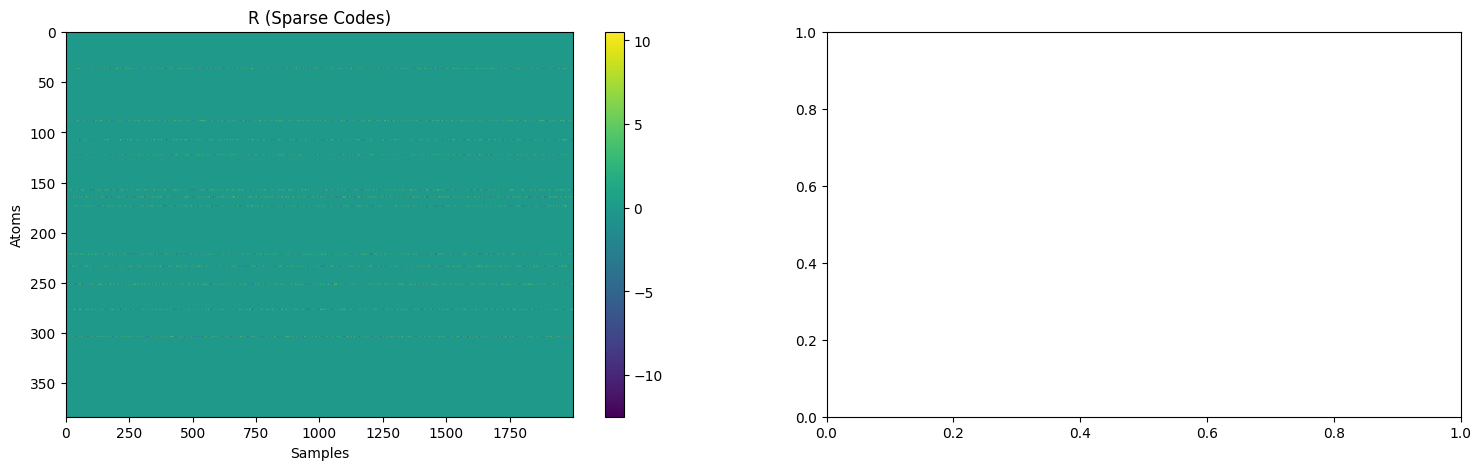

In [10]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Sparse codes
im0 = axes[0].imshow(R_np, aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
plt.colorbar(im0, ax=axes[0])



In [11]:
def create_correlated_datasets(X_base, n_users=3, n_total=200, n_shared=100):
    """
    Create correlated datasets by sharing columns with random permutation.

    X_base: (n_samples, d) numpy or torch
    Returns: dict {i: (d x n_total)}
    """

    if isinstance(X_base, np.ndarray):
        X_base = torch.tensor(X_base).float()

    N, d = X_base.shape

    # --- Step 1: pick shared pool ---
    shared_idx = torch.randperm(N)[:n_shared]
    X_shared = X_base[shared_idx]   # (n_shared, d)

    X_dict = {}

    for i in range(n_users):

        # --- Step 2: permute shared columns differently per user ---
        perm = torch.randperm(n_shared)
        X_shared_i = X_shared[perm]

        # --- Step 3: sample private data ---
        private_idx = torch.randperm(N)[:(n_total - n_shared)]
        X_private = X_base[private_idx]

        # --- Step 4: concatenate ---
        X_i = torch.cat([X_shared_i, X_private], dim=0)  # (n_total, d)

        # --- Step 5: shuffle columns globally ---
        shuffle = torch.randperm(n_total)
        X_i = X_i[shuffle]

        # --- Step 6: transpose to (d x n) ---
        X_dict[i] = X_i.T.contiguous()

    return X_dict

In [12]:
data_dir = "./data/"
X1 = np.load(data_dir + "mnist_emb_model1.npy")
X2 = np.load(data_dir + "mnist_emb_model2.npy")
X3 = np.load(data_dir + "mnist_emb_model3.npy")


#X_1 = StandardScaler().fit_transform(X1)
#X_1 = X_1  # -> (d, N)
#X_2 = StandardScaler().fit_transform(X2)
#X_2 = X_2  # -> (d, N)
#X_3 = StandardScaler().fit_transform(X3)
#X_3 = X_3  # -> (d, N)

norm = np.linalg.norm(X1, axis=0, keepdims=True)   # shape (1, n)
X_1 = X1 / norm
norm = np.linalg.norm(X2, axis=0, keepdims=True)   # shape (1, n)
X_2 = X2 / norm
norm = np.linalg.norm(X3, axis=0, keepdims=True)   # shape (1, n)
X_3 = X3 / norm


d, N = X_1.shape
K = int(X_1.shape[0] * 3.0)
k_sparsity = int(d * 0.1)

print(f"d: {d}, N: {N}, K: {K}, k_sparsity: {k_sparsity}")
print("Data shape:", X_1.shape, X_2.shape, X_3.shape)



X_dict = {
    0: torch.tensor(X_1.T).float(),  # (d x n)
    1: torch.tensor(X_2.T).float(),
    2: torch.tensor(X_3.T).float()
}
""" 
X_dict = create_correlated_datasets(
    X_base=X_1,   # your original dataset
    n_users=3,
    n_total=d,
    n_shared=50   # 40% shared
)
 """

d: 60000, N: 128, K: 180000, k_sparsity: 6000
Data shape: (60000, 128) (60000, 128) (60000, 128)


' \nX_dict = create_correlated_datasets(\n    X_base=X_1,   # your original dataset\n    n_users=3,\n    n_total=d,\n    n_shared=50   # 40% shared\n)\n '

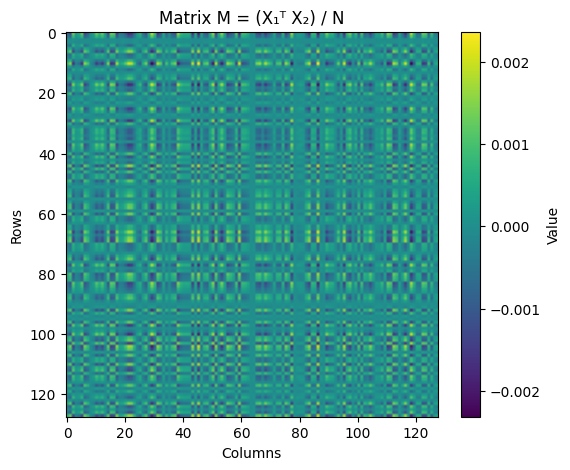

In [13]:
M = (X_dict[0] @ X_dict[1].T) / N

plt.figure(figsize=(6, 5))
plt.imshow(M, cmap='viridis', aspect='auto')
plt.colorbar(label='Value')
plt.title("Matrix M = (X₁ᵀ X₂) / N")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [14]:
from utils import MultiUserADMMDict

d = X1.shape[1]   # embedding dimension
K = int(X_emb.shape[0] * 2.0)           # number of atoms
k_sparsity = int(d * 0.9)   # number of active atoms

model = MultiUserADMMDict(
    d=d,
    K=n_atoms,
    k_sparsity=k_sparsity,
    rho=1.0,
    admm_iters=30
)

In [15]:
D, S_list, losses = model.fit(X_dict, outer_iters=100)

iter 0: loss=1.197260
iter 1: loss=0.335781
iter 2: loss=0.173681
iter 3: loss=0.107196
iter 4: loss=0.083948
iter 5: loss=0.054475
iter 6: loss=0.043874
iter 7: loss=0.037864
iter 8: loss=0.041322
iter 9: loss=0.052282
iter 10: loss=0.048702
iter 11: loss=0.051959
iter 12: loss=0.047324
iter 13: loss=0.037533
iter 14: loss=0.029108
iter 15: loss=0.034783
iter 16: loss=0.030211
iter 17: loss=0.029509
iter 18: loss=0.028911
iter 19: loss=0.053455
iter 20: loss=0.031825
iter 21: loss=0.032188
iter 22: loss=0.029647
iter 23: loss=0.029024
iter 24: loss=0.025056
iter 25: loss=0.023603
iter 26: loss=0.022963
iter 27: loss=0.022263
iter 28: loss=0.024362
iter 29: loss=0.022007
iter 30: loss=0.021779
iter 31: loss=0.021328
iter 32: loss=0.022962
iter 33: loss=0.022850
iter 34: loss=0.021316
iter 35: loss=0.025454
iter 36: loss=0.029407
iter 37: loss=0.025779
iter 38: loss=0.024064
iter 39: loss=0.077490
iter 40: loss=0.029353
iter 41: loss=0.024391
iter 42: loss=0.022875
iter 43: loss=0.02151

In [16]:
X_np = X_dict[2].detach().cpu().numpy()
D_np = D.detach().cpu().numpy()
R_np = S_list[2].detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="Admm"
)


===== Admm =====
Avg error: 0.5033
Std error: 0.1560
Avg sparsity: 113.09
Sparsity ratio: 0.4418


In [17]:

eps = 1e-4

row_nnz = torch.sum(torch.abs(S_list[2]) > eps, dim=1)
row_sparsity_ratio = row_nnz.float() / S_list[2].shape[1]
print(torch.sum(row_nnz > 0))
print(torch.sum(row_sparsity_ratio))

tensor(115, device='cuda:0')
tensor(113.0901, device='cuda:0')


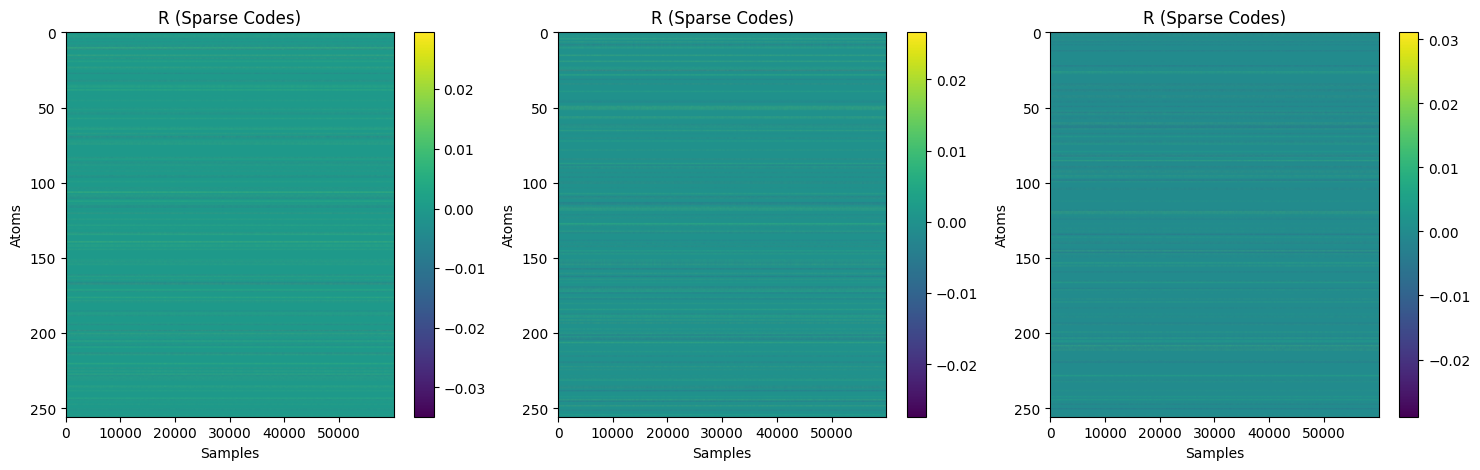

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sparse codes
im0 = axes[0].imshow(S_list[0].detach().cpu().numpy(), aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
plt.colorbar(im0, ax=axes[0])

# Sparse codes
im1 = axes[1].imshow(S_list[1].detach().cpu().numpy(), aspect="auto", cmap="viridis")
axes[1].set_title("R (Sparse Codes)")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Atoms")
plt.colorbar(im1, ax=axes[1])


# Sparse codes
im2 = axes[2].imshow(S_list[2].detach().cpu().numpy(), aspect="auto", cmap="viridis")
axes[2].set_title("R (Sparse Codes)")
axes[2].set_xlabel("Samples")
axes[2].set_ylabel("Atoms")
plt.colorbar(im2, ax=axes[2])

In [19]:
from utils import MultiUserSheafDict

num_users = 3



# =========================================================
# DEFINE GRAPH
# =========================================================
edges = [
    (0, 1),
    (1, 2),
    (0, 2)
]

# =========================================================
# MODEL
# =========================================================
d, N = X_1.T.shape
print(d, N)
K = int(d * 1.0)
k_sparsity = int(d * 0.1)

model = MultiUserSheafDict(
    d=d,
    K=K,
    edges=edges,
    k_sparsity=k_sparsity,
    mu=0.01,
    rho=1.0,
    admm_iters=20,
    update_O_every=True
)

# =========================================================
# TRAIN
# =========================================================
D, S_list, O, losses = model.fit(X_dict, outer_iters=100)

# =========================================================
# EVALUATION
# =========================================================
print("\n===== FINAL EVALUATION =====")

recon_error = 0.0
sparsity = 0.0

for i, X_i in X_dict.items():
    X_i = X_i.to(device)
    S_i = S_list[i]

    recon = model.D @ S_i
    recon_error += torch.norm(X_i - recon).item()

    sparsity += torch.mean((S_i.abs() > 1e-6).float()).item()

print(f"Reconstruction error: {recon_error:.4f}")
print(f"Sparsity: {sparsity / num_users:.4f}")

# =========================================================
# CHECK O MATRICES
# =========================================================
for edge, O_uv in O.items():
    O_uv = O_uv.cpu()
    ortho_error = torch.norm(O_uv.T @ O_uv - torch.eye(d))
    print(f"Edge {edge}: Orthogonality error = {ortho_error:.6f}")

128 60000
Iter   0: recon=259.9677 sheaf=35.1988 total=260.3197
Iter   1: recon=41.8747 sheaf=445.1021 total=46.3257
Iter   2: recon=10.1956 sheaf=552.0734 total=15.7163
Iter   3: recon=4.9774 sheaf=584.8978 total=10.8263
Iter   4: recon=3.6232 sheaf=600.0106 total=9.6233
Iter   5: recon=3.1818 sheaf=606.9601 total=9.2514
Iter   6: recon=2.9864 sheaf=610.6927 total=9.0933
Iter   7: recon=2.8665 sheaf=613.3311 total=8.9998
Iter   8: recon=2.7671 sheaf=615.7159 total=8.9243
Iter   9: recon=2.6876 sheaf=617.7489 total=8.8651
Iter  10: recon=2.6211 sheaf=619.5720 total=8.8168
Iter  11: recon=2.5762 sheaf=620.8220 total=8.7844
Iter  12: recon=2.5462 sheaf=621.7086 total=8.7633
Iter  13: recon=2.5253 sheaf=622.3578 total=8.7488
Iter  14: recon=2.5085 sheaf=622.9202 total=8.7377
Iter  15: recon=2.4978 sheaf=623.2804 total=8.7306
Iter  16: recon=2.4898 sheaf=623.5557 total=8.7254
Iter  17: recon=2.4855 sheaf=623.6864 total=8.7223
Iter  18: recon=2.4787 sheaf=623.9409 total=8.7181
Iter  19: rec

In [20]:
X_np = X_dict[1].detach().cpu().numpy()
D_np = D.detach().cpu().numpy()
R_np = S_list[1].detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="Admm"
)

sheaf_loss = 0.0
for (u, v) in model.edges:
    # Map user IDs to integer indices
    i = u
    j = v
    
    # Retrieve sparse codes for users u and v
    S_u = S_list[i]   # or model.current_S[i] if stored
    S_v = S_list[j]
    X_v = X_dict[j].to(device)
    # Orthogonal map for this edge
    O_uv = model.O[(u, v)]
    
    # Reconstructions
    DSu = model.D @ S_u
    DSv = model.D @ S_v
    
    # Sheaf penalty term
    diff = O_uv @ DSu - DSv
    sheaf_loss += torch.norm(diff, 'fro') ** 2
    percentage_error = torch.norm(diff, 'fro') ** 2 / torch.norm(DSv, 'fro') ** 2 * 100
    print(f"Edge: {(u, v)}: error: {percentage_error}")
print(f"Sheaf loss: {sheaf_loss.item():.4f}")


===== Admm =====
Avg error: 8.6447
Std error: 1.7946
Avg sparsity: 11.96
Sparsity ratio: 0.0934
Edge: (0, 1): error: 175.208740234375
Edge: (1, 2): error: 175.63888549804688
Edge: (0, 2): error: 176.74160766601562
Sheaf loss: 625.9603


In [21]:
from utils import MultiUserSheafFixedDict

num_users = 3



# =========================================================
# DEFINE GRAPH
# =========================================================
edges = [
    (0, 1),
    (1, 2),
    (0, 2)
]

# =========================================================
# MODEL
# =========================================================
d, N = X_1.T.shape
print(d, N)
K = int(d * 1.0)
k_sparsity = int(d * 0.1)

print(K)

model = MultiUserSheafFixedDict(
    d=d,
    K=K,
    edges=edges,
    k_sparsity=k_sparsity,
    mu=0.01,
    rho=1.0,
    admm_iters=20,
    update_O_every=True
)

# =========================================================
# TRAIN
# =========================================================
D, S_list, O, losses = model.fit(X_dict, outer_iters=100)

# =========================================================
# EVALUATION
# =========================================================
print("\n===== FINAL EVALUATION =====")

recon_error = 0.0
sparsity = 0.0

for i, X_i in X_dict.items():
    X_i = X_i.to(device)
    S_i = S_list[i]

    recon = model.D @ S_i
    recon_error += torch.norm(X_i - recon).item()

    sparsity += torch.mean((S_i.abs() > 1e-6).float()).item()

print(f"Reconstruction error: {recon_error:.4f}")
print(f"Sparsity: {sparsity / num_users:.4f}")

# =========================================================
# CHECK O MATRICES
# =========================================================
for edge, O_uv in O.items():
    O_uv = O_uv.cpu()
    ortho_error = torch.norm(O_uv.T @ O_uv - torch.eye(d))
    print(f"Edge {edge}: Orthogonality error = {ortho_error:.6f}")

128 60000
128
Iter 0: Recon=232.8907, Sheaf=50.8754
Iter 1: Recon=1.8148, Sheaf=685.5090
Iter 2: Recon=1.6072, Sheaf=698.1165
Iter 3: Recon=1.5925, Sheaf=699.8948
Iter 4: Recon=1.5866, Sheaf=700.7013
Iter 5: Recon=1.5836, Sheaf=701.1908
Iter 6: Recon=1.5820, Sheaf=701.5323
Iter 7: Recon=1.5809, Sheaf=701.7802
Iter 8: Recon=1.5803, Sheaf=701.9653
Iter 9: Recon=1.5798, Sheaf=702.1254
Iter 10: Recon=1.5795, Sheaf=702.2330
Iter 11: Recon=1.5793, Sheaf=702.3409
Iter 12: Recon=1.5791, Sheaf=702.4135
Iter 13: Recon=1.5789, Sheaf=702.4899
Iter 14: Recon=1.5788, Sheaf=702.5502
Iter 15: Recon=1.5786, Sheaf=702.6044
Iter 16: Recon=1.5785, Sheaf=702.6410
Iter 17: Recon=1.5783, Sheaf=702.6807
Iter 18: Recon=1.5782, Sheaf=702.7152
Iter 19: Recon=1.5780, Sheaf=702.7444
Iter 20: Recon=1.5778, Sheaf=702.7700
Iter 21: Recon=1.5777, Sheaf=702.7883
Iter 22: Recon=1.5775, Sheaf=702.8104
Iter 23: Recon=1.5773, Sheaf=702.8300
Iter 24: Recon=1.5771, Sheaf=702.8387
Iter 25: Recon=1.5769, Sheaf=702.8557
Iter 26

In [22]:
X_np = X_dict[1].detach().cpu().numpy()
D_np = D.detach().cpu().numpy()
R_np = S_list[1].detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="Admm"
)

sheaf_loss = 0.0
for (u, v) in model.edges:
    # Map user IDs to integer indices
    i = u
    j = v
    
    # Retrieve sparse codes for users u and v
    S_u = S_list[i]   # or model.current_S[i] if stored
    S_v = S_list[j]
    X_v = X_dict[j].to(device)
    # Orthogonal map for this edge
    O_uv = model.O[(u, v)]
    
    # Reconstructions
    DSu = model.D @ S_u
    DSv = model.D @ S_v
    
    # Sheaf penalty term
    diff = O_uv @ DSu - DSv
    sheaf_loss += torch.norm(diff, 'fro') ** 2
    percentage_error = torch.norm(diff, 'fro') ** 2 / torch.norm(DSv, 'fro') ** 2 * 100
    print(f"Edge: {(u, v)}: error: {percentage_error}")
print(f"Sheaf loss: {sheaf_loss.item():.4f}")


===== Admm =====
Avg error: 7.0565
Std error: 1.7277
Avg sparsity: 11.95
Sparsity ratio: 0.0934
Edge: (0, 1): error: 183.20205688476562
Edge: (1, 2): error: 183.6551513671875
Edge: (0, 2): error: 184.53671264648438
Sheaf loss: 702.8953


In [23]:
u, v = edges[0]

X_u = X_dict[u].detach().cpu().numpy()
D_ = D.detach().cpu().numpy()
S_u = S_list[u].detach().cpu().numpy()

X_v = X_dict[v].detach().cpu().numpy()
S_v = S_list[v].detach().cpu().numpy()



O_uv = model.O[(u, v)].cpu()
M = S_u @ S_v.T / N
U, _, VH = np.linalg.svd(M, full_matrices=False)
O_temp = VH.T @ U.T
print((O_temp))
# Reconstructions
DSu = D_ @ S_u
DSv = D_ @ S_v

# Sheaf penalty term
diff = O_uv @ S_u - S_v
sheaf_loss += np.linalg.norm(diff, 'fro') ** 2
percentage_error = (np.linalg.norm(diff, 'fro') ** 2 / np.linalg.norm(S_v, 'fro') ** 2) * 100
print(f"Edge: {(u, v)}: error: {percentage_error}")

[[ 1.0000000e+00  0.0000000e+00  0.0000000e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00 -2.7503884e-13  4.7818788e-15 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  9.5017117e-01 -9.5972963e-02 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 ...
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ...  1.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ...  0.0000000e+00
   1.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ...  0.0000000e+00
   0.0000000e+00  1.0000000e+00]]
Edge: (0, 1): error: 197.42364501953125


C:\Users\abdu_\AppData\Local\Temp\ipykernel_31564\1143112634.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff = O_uv @ S_u - S_v


In [24]:
print(S_u.shape, S_v.shape, D.shape, X_u.shape)

(128, 60000) (128, 60000) torch.Size([128, 128]) (128, 60000)


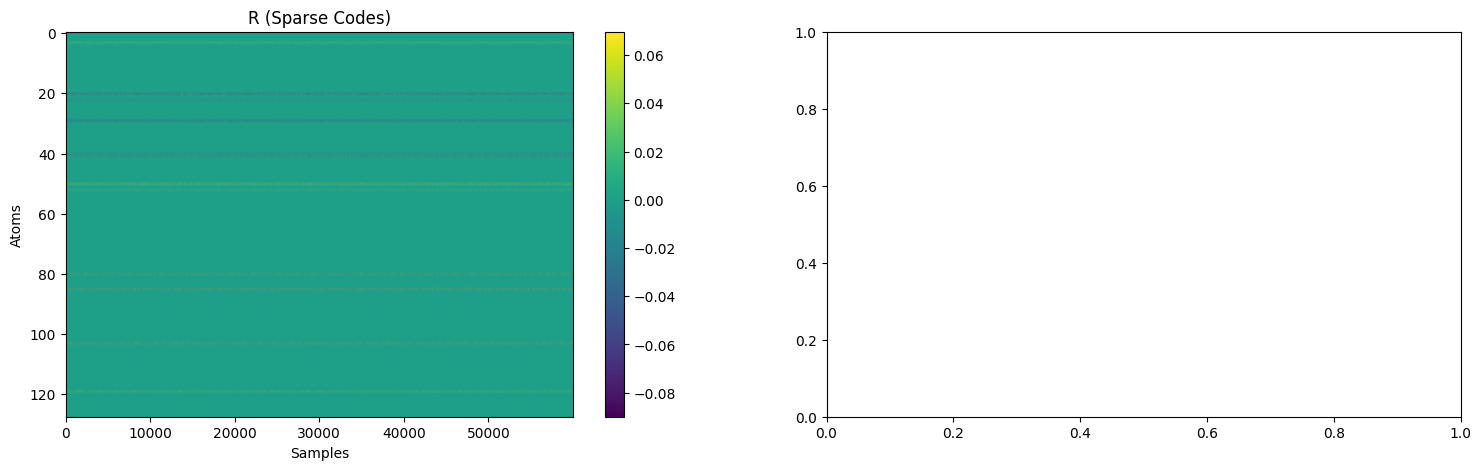

In [25]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Sparse codes
im0 = axes[0].imshow(S_u, aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
plt.colorbar(im0, ax=axes[0])

